# Sudoku Detector & Solver

Detect a Sudoku puzzle from a photo, read the digits with a CNN, solve it with backtracking, and overlay the solution on the original image.

**Pipeline:** Image → Grid Detection → Cell Extraction → Digit CNN → Solver → Overlay

**Time target: 3 hours**

| Hour | Sections |
|------|----------|
| 1 | Setup · Load image · Grid detection · Perspective warp · Cell extraction |
| 2 | CNN digit classifier (train on Colab) · Load weights · Read the puzzle |
| 3 | Backtracking solver · Solution overlay · End-to-end pipeline |

## Section 1 — Imports & Setup

We use only standard libraries — no dataset downloads needed.

- **OpenCV** — image processing, contour detection, perspective transform
- **NumPy** — array math
- **Matplotlib** — displaying images inline
- **PyTorch** — CNN digit classifier (trained on Colab, loaded here for inference)
- **Pillow** — image conversion helpers

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from PIL import Image



print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)
                    


OpenCV: 4.11.0
PyTorch: 2.2.2
cpu


## Section 2 — Load & Explore the Input Image

Drop your Sudoku photo into `data/raw/` and set the path below. We'll load it and display it to make sure OpenCV reads it correctly before doing any processing.


Image shape: (900, 900, 3)


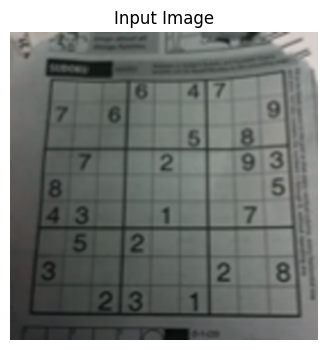

In [27]:
IMAGE_PATH = Path("../data/image.png")

img = cv2.imread(str(IMAGE_PATH))
img_resized = cv2.resize(img, (900, 900), interpolation=cv2.INTER_CUBIC)
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

print(f"Image shape: {img_resized.shape}")  # (height, width, channels = 3 colored photo)

plt.figure(figsize=(4, 4))
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")
plt.show()


## Section 3 — Grid Detection

**Goal:** Find the Sudoku grid in the photo and isolate it.

Steps:
1. Convert to grayscale
2. Gaussian blur to reduce noise
3. Adaptive threshold → binary image
4. Find all contours
5. Pick the largest 4-sided contour — that's the grid
6. Get its 4 corner points (top-left, top-right, bottom-right, bottom-left)

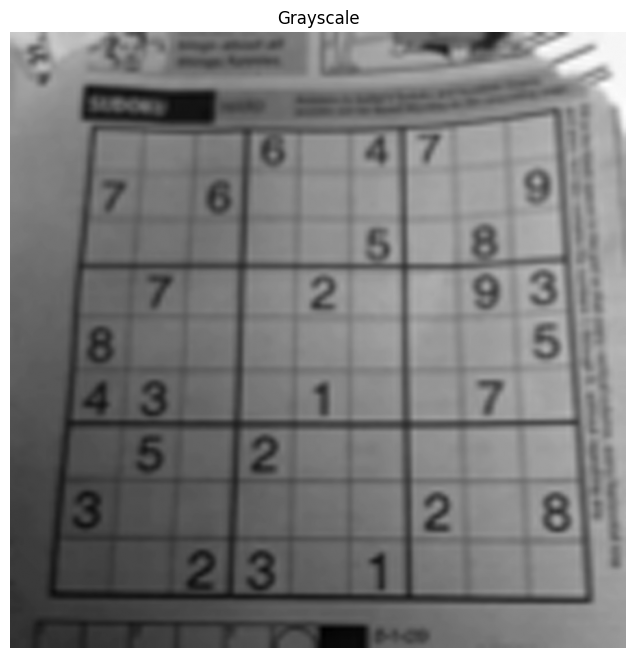

In [28]:
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()


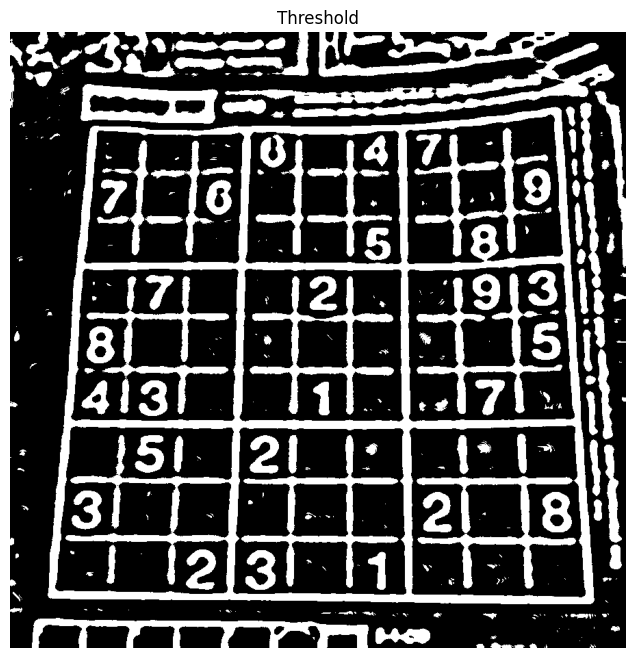

In [29]:
# Step 2 — Invert grayscale + adaptive threshold (MEAN_C works better for grid lines)

thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV,25, 2)

plt.figure(figsize=(8, 8))
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")
plt.show()


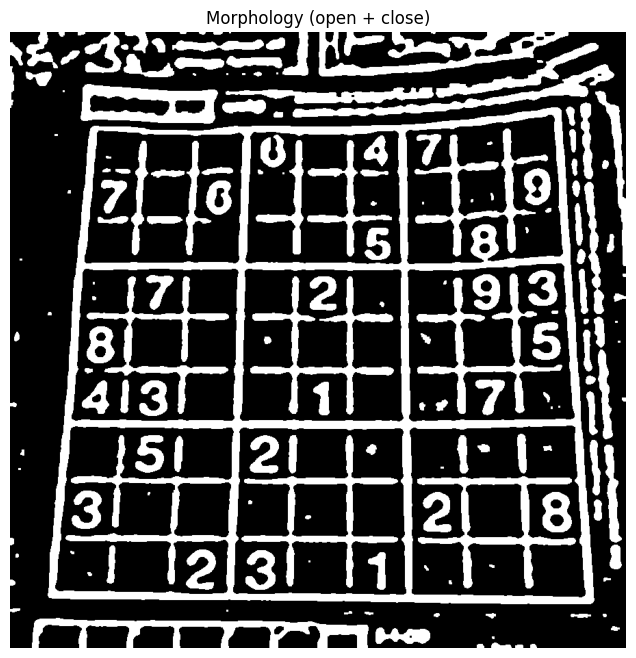

In [30]:
# Step 3 — Morphology: open removes noise spots, close fills gaps in lines
kernel = np.ones((3, 3), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(8, 8))
plt.imshow(morph, cmap="gray")
plt.title("Morphology (open + close)")
plt.axis("off")
plt.show()


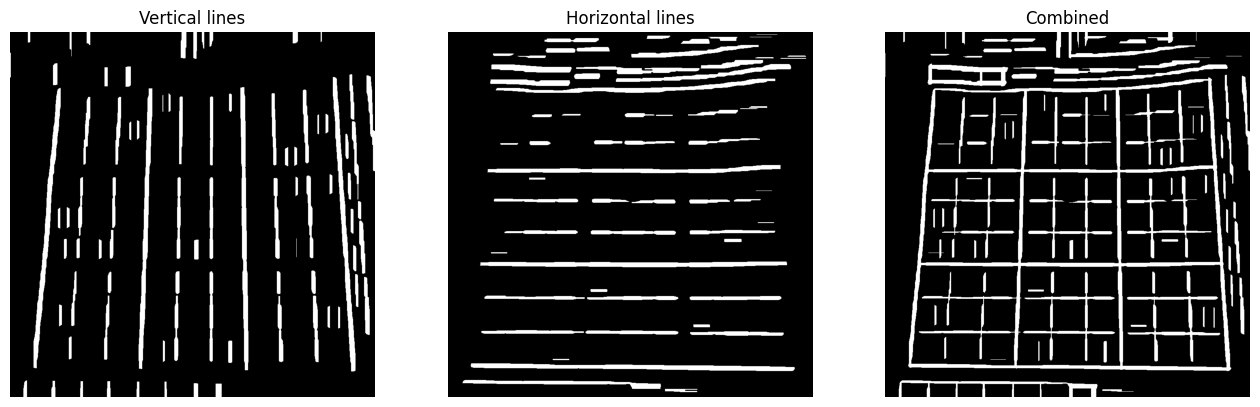

In [31]:
# Step 4 — Separate horizontal and vertical lines then combine
kernel_v = np.ones((40, 1), np.uint8)
vert = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_v)

kernel_h = np.ones((1, 40), np.uint8)
horiz = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_h)

grid_lines = cv2.add(horiz, vert)

# thin the lines
kernel = np.ones((3, 3), np.uint8)
grid_lines = cv2.morphologyEx(grid_lines, cv2.MORPH_ERODE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(vert, cmap="gray");   axes[0].set_title("Vertical lines");   axes[0].axis("off")
axes[1].imshow(horiz, cmap="gray");  axes[1].set_title("Horizontal lines"); axes[1].axis("off")
axes[2].imshow(grid_lines, cmap="gray"); axes[2].set_title("Combined");     axes[2].axis("off")
plt.show()


In [32]:
# Step 5 — Find the grid contour and get its 4 corners with minAreaRect
contours, _ = cv2.findContours(grid_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
big_contour = max(contours, key=cv2.contourArea)

epsilon = 0.02 * cv2.arcLength(big_contour, True)
approx = cv2.approxPolyDP(big_contour, epsilon, True)

print(f"Number of corners: {len(approx)}")


Number of corners: 4


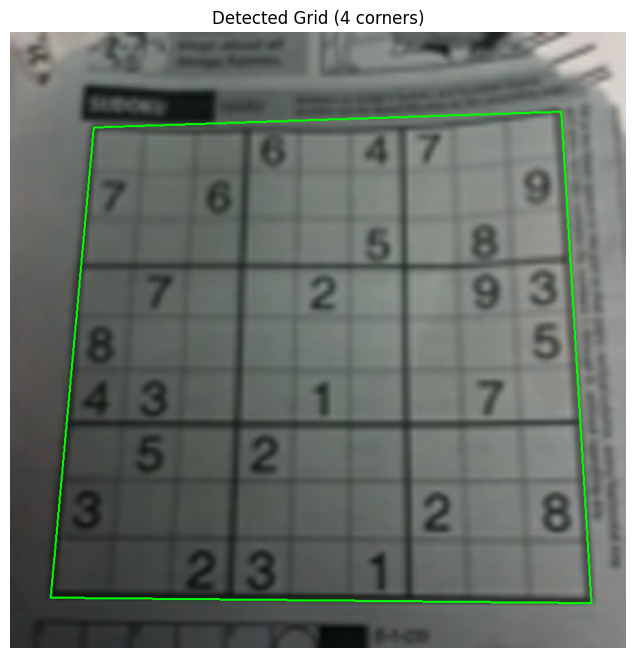

In [33]:
# Draw the clean 4-corner box on the original image to verify
debug = img_resized.copy()
cv2.drawContours(debug, [approx], 0, (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(debug)
plt.title("Detected Grid (4 corners)")
plt.axis("off")
plt.show()


In [34]:
print(approx)

[[[805 116]]

 [[122 139]]

 [[ 59 826]]

 [[849 834]]]


## Section 4 — Perspective Warp

**Goal:** Flatten the grid into a perfect top-down square (450×450 px).

Once we have the 4 corners, `cv2.getPerspectiveTransform` + `cv2.warpPerspective` maps them to a fixed rectangle. After this step we have a clean, square grid regardless of the camera angle.

In [35]:
# Section 4 — Perspective warp
# Sort corners into correct order
pts = approx.reshape(4, 2)  # reshape for easier access

# top-left = smallest x + smallest y
# top-right = largest x + smallest y
# bottom-right = largest x + largest y
# bottom-left = smallest x + largest y

sums = pts[:, 0] + pts[:, 1]   # gives x+y for each point
diffs = pts[:, 0] - pts[:, 1]  # gives x-y for each point

top_left = pts[np.argmin(sums)]
top_right = pts[np.argmax(diffs)]
bottom_right = pts[np.argmax(sums)]
bottom_left = pts[np.argmin(diffs)]


# Stack into ordered array
corners = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

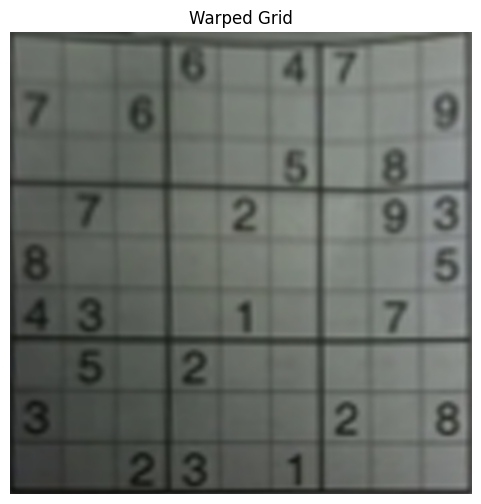

In [49]:
size = 900
dst = np.array([
    [0, 0],
    [900, 0],
    [900, 900],
    [0, 900]
], dtype=np.float32)

M = cv2.getPerspectiveTransform(corners, dst)
warped = cv2.warpPerspective(img_resized, M, (size, size))

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Warped Grid")
plt.axis("off")
plt.show()

## Section 5 — Cell Extraction

**Goal:** Split the warped 450×450 grid into 81 individual cells (50×50 px each).

We divide into a 9×9 grid. Each cell gets a small center crop to strip away the grid lines, leaving only the digit (or blank space).

In [81]:
# Section 5 — Cell extraction
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
warped_thresh = cv2.adaptiveThreshold(
    warped_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

cell_size = 100
cells = []

for row in range(9):
    for col in range(9):
        y_start = row * cell_size
        y_end = (row + 1) * cell_size
        x_start = col * cell_size
        x_end = (col + 1) * cell_size
        
        cell = warped_thresh[y_start:y_end, x_start:x_end]
        center = cell[10:-10, 10:-10]   # remove grid lines
        cell = cv2.resize(center, (28, 28))  # resize for CNN
        
        white_pixels = cv2.countNonZero(cell)
        if white_pixels < 68:
            cells.append(0)  # empty
        else:
            cells.append(cell)  # has digit → CNN later

# Check results
empty = sum(1 for c in cells if isinstance(c, int))
print(f"Empty cells: {empty}")
print(f"Cells with digits: {81 - empty}")

print(f"Total cells extracted: {len(cells)}")

Empty cells: 56
Cells with digits: 25
Total cells extracted: 81


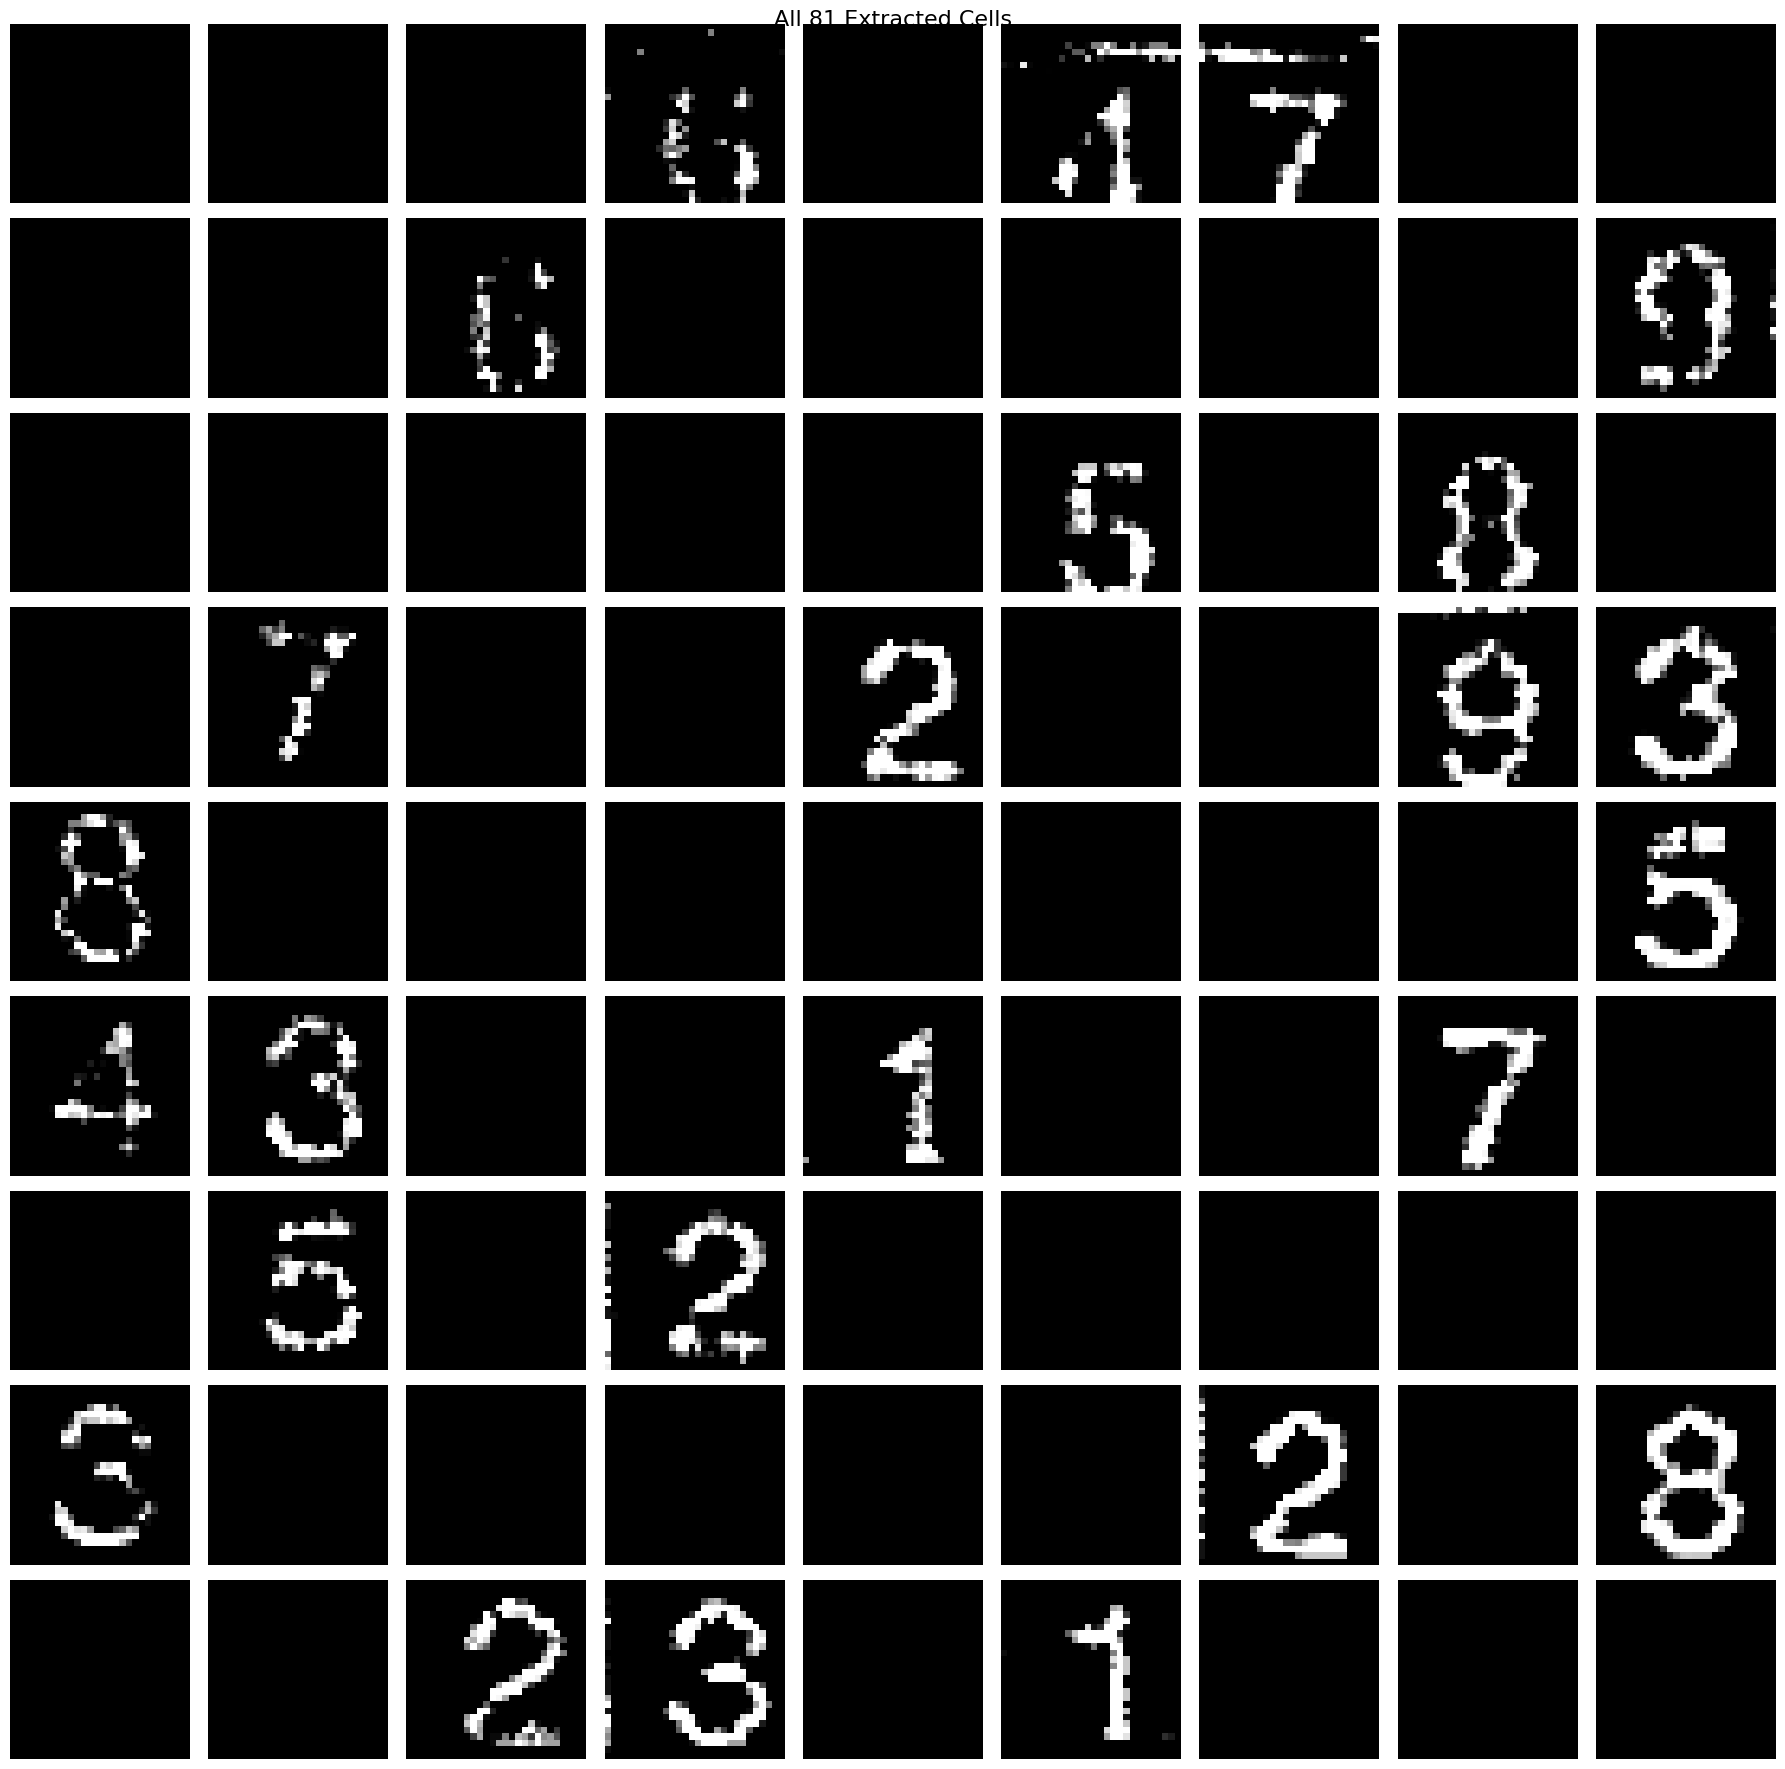

In [82]:
# Visualize all 81 extracted cells
fig, axes = plt.subplots(9, 9, figsize=(18, 18))
for row in range(9):
    for col in range(9):
        idx = row * 9 + col
        if isinstance(cells[idx], int):
            axes[row][col].imshow(np.zeros((28, 28)), cmap='gray')
        else:
            axes[row][col].imshow(cells[idx], cmap='gray')
        axes[row][col].axis('off')

plt.suptitle('All 81 Extracted Cells', fontsize=16)
plt.tight_layout()
plt.savefig('cells_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — CNN Digit Classifier

**Goal:** Classify each cell as empty (0) or a digit 1–9.

In [38]:
# Section 6 — CNN architecture 
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 → relu → pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 → relu → pool
        x = x.view(-1, 1600)  # flatten
        x = self.dropout(x)  # dropout
        x = F.relu(self.fc1(x))  # fc1 → relu
        x = self.fc2(x) # fc2 (final output)
        return x

In [14]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='../data', 
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True
)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total batches: {len(train_loader)}")

Total training samples: 60000
Total batches: 938


In [17]:
# 1. Model
model = DigitCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. Training loop
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'digit_cnn.pt')

In [39]:
model.load_state_dict(torch.load('digit_cnn.pt'))
model.eval()

print(" Model loaded successfully!")

 Model loaded successfully!


In [40]:
# Load test set
test_dataset = datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Test accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = outputs.argmax(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 99.10%


## Section 7 — Read the Puzzle

**Goal:** Run the CNN on all 81 cells and reconstruct the 9×9 puzzle grid.

Output is a 9×9 NumPy array where `0` = empty cell and `1–9` = given digit. We'll print it as a grid and visually verify a few cells before solving.

In [41]:
# Section 7 — Load model weights + run inference on all 81 cells
def predict_digit(cell):
    model.eval()
    with torch.no_grad():
        # 1. Convert to tensor
        tensor = torch.tensor(cell, dtype=torch.float32)
        
        # 2. Normalize p
        tensor = tensor / 255
        
        # 3. Add dimensions [1, 1, 28, 28]
        tensor = tensor.unsqueeze(0).unsqueeze(0)
        
        # 4. Get prediction
        output = model(tensor)
        prediction = output.argmax(1)
        
    return prediction.item()

In [76]:
puzzle = []

for row in range(9):
    puzzle_row = []
    for col in range(9):
        cell = cells[row * 9 + col]
        
        if isinstance(cell, int):  # empty cell
            puzzle_row.append(0)
        else:
            digit = predict_digit(cell)
            puzzle_row.append(digit)
    
    puzzle.append(puzzle_row)

# Print puzzle
puzzle = np.array(puzzle)
print(puzzle)

[[0 0 0 8 0 5 7 0 0]
 [0 0 8 0 0 0 0 0 9]
 [0 0 0 0 0 5 0 8 0]
 [0 3 0 0 2 0 0 9 3]
 [8 0 0 0 0 0 0 0 5]
 [2 0 0 0 7 0 0 7 0]
 [0 5 0 2 0 0 0 0 0]
 [3 0 0 0 0 0 2 0 8]
 [0 0 2 3 0 7 0 0 0]]


Since it didn't predict all correctly ... we will try another approach ... later :)

## Section 8 — Backtracking Solver

**Goal:** Solve the 9×9 puzzle.

### Algorithm
Classic recursive backtracking:
1. Find the next empty cell (value = 0)
2. Try digits 1–9
3. Check if the digit is valid (not already in same row, column, or 3×3 box)
4. If valid, place it and recurse
5. If no digit works, backtrack

Worst case is slow, but most real Sudoku puzzles solve in milliseconds.

In [ ]:
# Section 8 — Backtracking solver
def is_valid(puzzle, row, col, num):
    # Check 1: num not in same row
    if num in puzzle[row]:
        return False
    
    # Check 2: num not in same col
    if num in puzzle[col]:
        return False
    
    # Check 3: num not in same 3x3 box
    box_row = (row // 3) * 3
    box_col = (col // 3) * 3
    for i in range(3):
        for j in range(3):
            if puzzle[box_row + i][box_col + j] == num:
                return False
    
    return True


In [87]:
def solve(puzzle):
    # Find next empty cell (value = 0)
    for row in range(9):
        for col in range(9):
            if puzzle[row][col] == 0:
                
                # Try digits 1-9
                for num in range(1, 10):
                    if is_valid(puzzle, row, col, num):
                        
                        # Place the digit
                        puzzle[row][col] = num
                        
                        # Recurse!
                        if solve(puzzle):
                            return True
                        
                        # Backtrack if it didn't work
                        puzzle[row][col] =0
                
                return False  # no digit worked
    
    return True  # no empty cells left = solved!

In [96]:
# Test with correct puzzle
correct_puzzle = [
    [0, 0, 0, 6, 0, 4, 7, 0, 0],
    [7, 0, 6, 0, 0, 0, 0, 0, 9],
    [0, 0, 0, 0, 0, 5, 0, 8, 0],
    [0, 7, 0, 0, 2, 0, 0, 9, 3],
    [8, 0, 0, 0, 0, 0, 0, 0, 5],
    [4, 3, 0, 0, 1, 0, 0, 7, 0],
    [0, 5, 0, 2, 0, 0, 0, 0, 0],
    [3, 0, 0, 0, 0, 0, 2, 0, 8],
    [0, 0, 2, 3, 0, 1, 0, 0, 0]
]

import copy
solution = copy.deepcopy(correct_puzzle)

if solve(solution):
    print("✅ Solved!")
    for row in solution:
        print(row)
else:
    print("❌ No solution found")

✅ Solved!
[5, 8, 3, 6, 9, 4, 7, 2, 1]
[7, 1, 6, 8, 3, 2, 5, 4, 9]
[2, 9, 4, 1, 7, 5, 3, 8, 6]
[6, 7, 1, 5, 2, 8, 4, 9, 3]
[8, 2, 9, 7, 4, 3, 1, 6, 5]
[4, 3, 5, 9, 1, 6, 8, 7, 2]
[1, 5, 8, 2, 6, 7, 9, 3, 4]
[3, 6, 7, 4, 5, 9, 2, 1, 8]
[9, 4, 2, 3, 8, 1, 6, 5, 7]


## Section 9 — Solution Overlay

**Goal:** Draw the solved digits back onto the original image.

We reverse the perspective warp (`cv2.warpPerspective` with the inverse matrix) to map the solution digits back into the original photo's perspective, then blend it over the original. Cells that were empty (filled by the solver) are shown in **blue** so it's clear what was added.

In [ ]:
# Section 9 — Solution overlay


## Section 10 — End-to-End Pipeline

**Goal:** Run the full pipeline in one shot on any image.

One function: `solve_sudoku_image(path)` → displays the original image with the solution overlaid. This ties together every section above.

In [ ]:
# Section 10 — End-to-end pipeline
